# How far ahead does the MILP need to look, and does the answer depend on the price list?

The same continuous MILP formulation, driven five ways over the same 30 kWh battery, on 40
households — 5 from each of the 8 Fluvius groups, full year — and on four GEN-I price lists.
Two axes, crossed: every strategy is run on every list, on every household.

### The strategy axis

| | |
|---|---|
| **horizon** | how far each solve sees: day (96 intervals), week (672), month, or the whole year |
| **execution** | `block` — carry out the entire plan, then re-plan · `receding` — carry out the first interval only, then re-plan (MPC) |
| **SOC mode** | `fixed50` — every solve starts and ends at 50 % of capacity · `carry` — only the first period starts at 50 %, then each period starts where the last one ended |

### The price-list axis

Four GEN-I household products, all billed and optimized under `si_samooskrba`:

| List | `paket_id` | Import price [EUR/kWh] | Export credit [EUR/kWh] | How fast the price moves |
|---|---|---|---|---|
| **Dinamični** | `GENI_SAMO_DINAMICNI` | SIPX + 0.01199, uncapped | SIPX − 0.01199, per interval | every 15 minutes |
| **Aktivni** | `GENI_SAMO_AKTIVNI` | 4 blocks, 0.04090 → 0.19290 | 4 blocks, 0.00190 → 0.14990 | 4 fixed windows, same every day |
| **Redni 1T** | `GENI_SAMO_REDNI` | 0.10290 flat (ET) | 0.05390 flat | never |
| **Redni 2T** | `GENI_REDNI` | VT 0.11990 / MT 0.09790 | nothing — `tip_odkupa=NI` | VT 06:00–22:00 working days, MT otherwise |

`Redni 2T` runs on the no-PV groups only: GEN-I publishes no two-tariff samooskrba list, so
`GENI_REDNI` is a plain supply list with no buyback, and scoring a PV roof on it would read a
product-eligibility result as a tariff result.

How far ahead a controller has to look is a property of the price signal, which is why the
price list belongs on the same chart as the horizon.

`Gap_pct` is read within a list, not across: it is the share of that list's achievable saving,
so the whole-year solve is 0 % on all four by construction.

### What makes the comparison fair

The MILP only produces a dispatch; every executed trajectory is priced afterwards by one shared
evaluator walking interval by interval with a single running peak state. `_PeakSeedView` gives
each sub-solve the peak the executed trajectory has actually set. The year is always closed at
50 % under both SOC modes, so a free-terminal strategy cannot sell off its opening charge.

In [1]:
### Imports
import time
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch, Rectangle

import importlib
import Horizon_Comparison as hc
hc = importlib.reload(hc)

print(f"Horizon_Comparison loaded: {len(hc.TARIFFS)} price lists, "
      f"{len(hc.STRATEGIES)} strategies.")

Horizon_Comparison loaded: 4 price lists, 5 strategies.


## 1. Configuration

The study parameters live in `Horizon_Comparison.py`, including `TARIFFS`. `RUN_BATCH = True`
recomputes everything (~9 h on 10 workers); by default the notebook reads the CSVs the batch
already wrote. Work is checkpointed per (household, list).

In [2]:
UNITS = hc.study_units()          # (dataset group, household id) pairs
TARIFFS = list(hc.TARIFF_ORDER)   # price lists
JOBS = hc.study_jobs(UNITS, TARIFFS)   # scope-filtered: see TARIFFS["scope"]
RESULTS_DIR = hc.RESULTS_DIR
RUN_BATCH = True                 # True -> recompute (~9 h on 10 workers, resumable)
N_WORKERS = 10

print(f"groups             : {', '.join(hc.DATASET_GROUPS)}")
print(f"households         : {hc.HOUSEHOLDS_PER_GROUP} per group = {len(UNITS)} units")
print(f"battery            : {hc.BATTERY_CAPACITY_KWH:.0f} kWh, "
      f"{min(hc.C_RATE * hc.BATTERY_CAPACITY_KWH, hc.INVERTER_MAX_KW):.1f} kW, "
      f"eff {hc.CHARGE_EFFICIENCY:.2f}/{hc.DISCHARGE_EFFICIENCY:.2f}")
print(f"SOC                : start {hc.SOC_FRACTION:.0%}, "
      f"final period ends at {hc.SOC_FRACTION:.0%}; interior boundaries per SOC mode")
print(f"peak reset         : every {hc.PEAK_RESET_MONTHS} month(s), tag {hc.PEAK_RESET_TAG!r} "
      f"-- the excess-power charge is billed monthly, so the running peak it is "
      f"measured on drops on the 1st")
print(f"agreed power       : {hc.AGREED_POWER_TAG} -- the dogovorjena obracunska moc is "
      f"re-set every month to the previous month's own peak in each block, with no floor and "
      f"no connection-power ceiling; the leading month is bootstrapped {hc.AGREED_POWER_BOOTSTRAP!r}")
schemes = sorted({c["scheme"] for c in hc.TARIFFS.values()})
print(f"pricing regime     : {hc.PRICING_REFERENCE_YEAR}, scheme(s) {', '.join(schemes)}")
# Not one scheme for every list: a samooskrba list and a plain-supply list are
# settled differently, and the plain one is the no-PV shelf (scope below).

print(f"\nprice lists        : {len(TARIFFS)}")
for name in TARIFFS:
    spec = hc.TARIFFS[name]
    eligible = sorted({g for g in hc.DATASET_GROUPS if hc.tariff_allowed(name, g)})
    scope = "every group" if len(eligible) == len(hc.DATASET_GROUPS) else "no-PV groups only"
    print(f"   {name:11s} {spec['paket_id']:20s} {spec['structure']:20s} "
          f"{'exports credited' if spec['buyback'] else 'no buyback':17s} {scope}")

print(f"\nstrategies         : {len(hc.STRATEGIES)}")
for name, (horizon, execution, soc_mode) in hc.STRATEGIES.items():
    print(f"   {name:20s} horizon={horizon:7s} execution={execution:9s} soc={soc_mode}")

print(f"\njobs               : {len(JOBS)} (unit, list) pairs x {len(hc.STRATEGIES)} "
      f"strategies = {len(JOBS) * len(hc.STRATEGIES):,} runs")

groups             : Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV, Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV
households         : 5 per group = 40 units
battery            : 30 kWh, 11.0 kW, eff 0.95/0.95
SOC                : start 50%, final period ends at 50%; interior boundaries per SOC mode
peak reset         : every 1 month(s), tag '1m' -- the excess-power charge is billed monthly, so the running peak it is measured on drops on the 1st
agreed power       : prev1m_top5_cyclic_unbounded_dispatch -- the dogovorjena obracunska moc is re-set every month to the previous month's own peak in each block, with no floor and no connection-power ceiling; the leading month is bootstrapped 'cyclic'
pricing regime     : 2026, scheme(s) si_dobava, si_samooskrba

price lists        : 4
   Dinamični   GENI_SAMO_DINAMICNI  dynamic (SIPX)       exports credited  every group
   Aktivni     GENI_SAMO_AKTIVNI    4 time blocks        exports credited  every group
   Redni 1T    GENI_SAM

## 1b. The agreed billing power

Two of the three network lines are measured against one per-block kW vector, the *dogovorjena
obračunska moč*: the power charge is `agreed kW x block power rate` summed over the blocks in
the month, and the excess-power charge is what the realized peak does above that vector.

The rule modelled here: each month the household agrees exactly the peak power the previous
month realized, per block. No floor and no ceiling — both are terms of a connection agreement
the profiles do not carry — so the only rule applied is the Akt's monotonicity requirement,
`P1 ≤ P2 ≤ P3 ≤ P4 ≤ P5`. `hc.MIN_AGREED_POWER_KW` and `hc.CONNECTION_POWER_KW` put either
bound back.

### The first month, which has no previous month

| | what it uses | leading month's excess charge | leading month's power charge |
|---|---|---|---|
| **`cyclic`** (used here) | the last complete month of the same dataset | 0–12.60 EUR, mean **2.15** | mean 37.58 EUR |
| `own` | the leading month's own per-block peaks | 0.00, every household | mean 34.66 EUR |
| `flat_max` | the leading month's single largest draw, flat across blocks | 0.00, every household | mean 45.41 EUR |

Both alternatives put the agreed power at or above every peak in the month, so the leading
month can never pay an excess charge and contributes no peak-shaving signal. `cyclic` is the
only one under which it behaves like the other twelve.

The agreed power is not a constant in the objective. It is re-agreed each month from the peaks
the dispatch itself realized the month before, so `full_period` carries one variable per
(block, month) tied to the previous month's peak variables and settles the contract as part of
the optimum. The rolling strategies cannot decide it, so they roll it forward one month at
a time off their own executed meter and price the contract they are setting inside every
sub-solve as a shadow price built from the peaks the month has already metered
(`AGREED_POWER_ROLL`, `AGREED_POWER_SURROGATE`) — both causal, neither reading an interval
the controller has not executed. The
no-battery baseline keeps the no-battery contract. The bootstrap choice above still applies to
the leading month, which has no predecessor either way.

In [3]:
### The agreed-power schedule, and what the first month is set from
sched_unit = ("Fluvius_HP_EV", 1)          # a household whose winter peaks actually bite
sched_env = hc.build_env(hc.load_user(sched_unit[1], sched_unit[0]))

print(f"{sched_unit[0]} household {sched_unit[1]} -- rule {sched_env.agreed_power_rule!r}")
# The bootstrap is a per-block LIST of the highest peaks and not one number:
# the contract is the MEAN of the n_peaks largest, so the raw values have to
# survive. What they contract to is the first month's Agreed_Bn below.
boot = sched_env.agreed_power_bootstrap_kw
if boot is None:
    print(f"first month bootstrapped from its own peaks "
          f"({sched_env.agreed_power_bootstrap!r} reads no separate history)")
else:
    print(f"first month bootstrapped from the {sched_env.agreed_power_n_peaks} "
          f"highest peaks per block: "
          f"{ {b: [round(v, 2) for v in vals] for b, vals in sorted(boot.items())} }")
print("Agreed_Bn is what that month is billed on; Peak_Bn is the no-battery peak it was set from")
print("(Peak_Bn is NaN where the block does not occur: block 1 is higher-season only, block 5 lower)")
display(sched_env.agreed_power_frame().round(2))


Fluvius_HP_EV household 1 -- rule 'prev1m_top5_cyclic_unbounded'
first month bootstrapped from the 5 highest peaks per block: {1: [6.27, 6.02, 5.62, 5.59, 5.26], 2: [6.45, 6.45, 6.03, 6.01, 5.49], 3: [11.94, 11.92, 11.92, 11.92, 11.9], 4: [11.84, 11.78, 11.76, 11.74, 11.73]}
Agreed_Bn is what that month is billed on; Peak_Bn is the no-battery peak it was set from
(Peak_Bn is NaN where the block does not occur: block 1 is higher-season only, block 5 lower)


,Agreed_B1,Agreed_B2,Agreed_B3,Agreed_B4,Agreed_B5,Peak_B1,Peak_B2,Peak_B3,Peak_B4,Peak_B5
Month,,,,,,,,,,
2024-01,5.75,6.08,11.92,11.92,NaN,8.75,8.52,21.91,21.17,NaN
2024-02,8.57,8.57,21.88,21.88,NaN,10.39,7.51,21.69,21.38,NaN
2024-03,NaN,6.58,21.52,21.52,21.52,NaN,6.52,6.36,21.79,21.24
2024-04,NaN,6.38,6.38,21.70,21.70,NaN,9.79,6.56,11.98,6.81
2024-05,NaN,7.71,7.71,11.96,11.96,NaN,3.85,3.92,5.23,5.22
2024-06,NaN,3.49,3.78,4.88,4.88,NaN,4.72,3.68,3.90,2.16
2024-07,NaN,3.60,3.60,3.60,3.60,NaN,4.72,3.98,3.64,3.28
2024-08,NaN,4.22,4.22,4.22,4.22,NaN,3.11,3.92,2.94,2.24
2024-09,NaN,2.75,3.11,3.11,3.11,NaN,7.26,5.74,6.76,6.81


## 2. Load results

One CSV per (household, price list), keyed by `hc.KEY_COLUMNS`, because the whole-year optimum
a strategy is scored against is the optimum for that household on that list. Only units that
finished every strategy on every ready list enter the comparison.

In [4]:
if RUN_BATCH:
    hc.run_batch(UNITS, tariffs=TARIFFS, output_dir=RESULTS_DIR, n_workers=N_WORKERS)

# Rows priced under a superseded ratchet rule are dropped on the way in.
df_all = hc.collect_results(RESULTS_DIR)
if df_all.empty:
    raise SystemExit(
        f"No results in {RESULTS_DIR} priced under peak reset {hc.PEAK_RESET_TAG!r}.\n"
        f"Run  python Horizon_Comparison.py --per-group 5 --workers 10  (~9 h), "
        f"or set RUN_BATCH = True above."
    )

# The batch writes each CSV after every finished strategy.
expected = list(hc.STRATEGIES)
done = {k: set(g) for k, g in df_all.groupby(hc.KEY_COLUMNS)["Strategy"]}
complete_keys = {k for k, s in done.items() if set(expected) <= s}

# "Complete" is measured against each list's own eligible set.
eligible = {t: {u for u in UNITS if hc.tariff_allowed(t, u[0])} for t in TARIFFS}
units_done = {t: {(d, h) for d, h, t2 in complete_keys if t2 == t} for t in TARIFFS}
TARIFFS_READY = [t for t in TARIFFS if units_done[t]]
if not TARIFFS_READY:
    raise SystemExit(
        "No household-unit has every strategy on any price list yet, so there is nothing to "
        "compare against a whole-year optimum. Re-run once the batch has finished a unit "
        "(~1.2 h each)."
    )

print(f"{'price list':12s}{'complete units':>18s}{'runs on disk':>16s}")
for t in TARIFFS:
    rows = int((df_all['Tariff'] == t).sum())
    print(f"{t:12s}{len(units_done[t]):>12d} / {len(eligible[t]):<3d}"
          f"{rows:>11,d} / {len(eligible[t]) * len(expected):<,d}")
if len(TARIFFS_READY) < len(TARIFFS):
    print(f"\nNot started yet, and left out of everything below: "
          f"{', '.join(t for t in TARIFFS if t not in TARIFFS_READY)}")

# One balanced panel: a unit enters only if it is finished on every ready list it
# is eligible for, so a difference between lists is not a difference in sample.
balanced = {
    u for u in UNITS
    if any(u in units_done[t] for t in TARIFFS_READY)
    and all(u in units_done[t] for t in TARIFFS_READY if u in eligible[t])
}
if not balanced:
    raise SystemExit(
        "No household-unit is finished on every price list it is eligible for. Let the "
        "batch finish one unit across all lists."
    )
dropped = {t: len(units_done[t] - balanced) for t in TARIFFS_READY}
if any(dropped.values()):
    print("\nHeld out to keep the panel balanced (finished on some lists but not all): "
          + ", ".join(f"{t} {n}" for t, n in dropped.items() if n))

keys = pd.MultiIndex.from_tuples(
    [(d, h, t) for t in TARIFFS_READY for d, h in sorted(balanced) if (d, h) in eligible[t]],
    names=hc.KEY_COLUMNS,
)
df_all = df_all.set_index(hc.KEY_COLUMNS).loc[keys].reset_index()

per_list = df_all.groupby("Tariff")["Dataset"].size() // len(expected)
print(f"\nComparing {len(balanced)} units across {len(TARIFFS_READY)} price lists "
      f"({', '.join(f'{t}: {n}' for t, n in per_list.items())}) x {len(expected)} "
      f"strategies = {len(df_all)} runs, {df_all['N_Solves'].sum():,.0f} MILP solves, "
      f"{df_all['Runtime_s'].sum() / 3600:.1f} solver-hours.")
print(f"Max SOC drift over every run: {df_all['SOC_Drift_kWh'].max():.2e} kWh "
      f"(0 means no solve ever ended infeasible)")

done -> Fluvius_user_001.csv (5 strategies)


done -> Fluvius_user_001_aktivni.csv (5 strategies)


done -> Fluvius_user_002.csv (5 strategies)


done -> Fluvius_user_001_redni1t.csv (5 strategies)


done -> Fluvius_user_002_aktivni.csv (5 strategies)


...

done -> Fluvius_PV_HP_EV_user_004_redni1t.csv (5 strategies)


done -> Fluvius_PV_HP_EV_user_005.csv (5 strategies)


done -> Fluvius_PV_HP_EV_user_005_aktivni.csv (5 strategies)


done -> Fluvius_PV_HP_EV_user_005_redni1t.csv (5 strategies)


price list      complete units    runs on disk
Dinamični             40 / 40         200 / 200
Aktivni               40 / 40         200 / 200
Redni 1T              40 / 40         200 / 200
Redni 2T              20 / 20         100 / 100

Comparing 40 units across 4 price lists (Aktivni: 40, Dinamični: 40, Redni 1T: 40, Redni 2T: 20) x 5 strategies = 700 runs, 4,979,380 MILP solves, 105.3 solver-hours.
Max SOC drift over every run: 7.85e-06 kWh (0 means no solve ever ended infeasible)


## 3. The comparison table

    Gap_pct = 100 % − (no-battery cost − strategy cost) / (no-battery cost − whole-year optimum)

Both reference points are resolved per household and per price list, so `full_period` is 0 % on
every list by construction and bigger is worse. That makes the 40 households comparable to each
other despite bills differing by an order of magnitude.

It does not make the four price lists comparable in euros: the denominators differ by a large
factor, so read the percentages down a list and the `Achievable [EUR/a]` column across.

`Grid charged [%]` is the share of the battery's intake that came from the grid rather than
from the household's own surplus.

In [5]:
summary, df_scored = hc.summarize(df_all)

# The achievable saving: the denominator every Gap_pct on that list uses.
achievable = summary.xs(hc.REFERENCE_STRATEGY, level="Strategy")["Savings_EUR"]

# Two gap columns. "Vrzel [%]" is the mean over units clearing
# hc.MIN_ACHIEVABLE_EUR; "Gap pooled [%]" is summed gap over summed achievable,
# weighting every unit by the euros at stake. Quote the pooled one.
summary_display = summary.assign(
    Achievable_EUR=[achievable[t] for t, _ in summary.index],
    Grid_Charged_pct=100.0 * summary["Grid_Charged_kWh"] / summary["Charged_kWh"].where(lambda s: s > 0),
).drop(columns=["Charged_kWh", "Grid_Charged_kWh"])[[
    "Units", "SOC_Mode", "Gap_pct_pooled", "Gap_pct", "Worst_Gap_pct", "Best_Gap_pct",
    "Gap_EUR", "Achievable_EUR", "Cost_EUR", "Savings_EUR", "Cycles", "Grid_Charged_pct",
    "Peak_kW", "Solves", "Runtime_s",
]].rename(columns={
    "SOC_Mode": "SOC mode",
    "Gap_pct_pooled": "Gap pooled [%]",
    "Gap_pct": "Vrzel [%]",
    "Worst_Gap_pct": "Worst unit [%]",
    "Best_Gap_pct": "Best unit [%]",
    "Gap_EUR": "Gap [EUR/a]",
    "Achievable_EUR": "Achievable [EUR/a]",
    "Cost_EUR": "Cost [EUR/a]",
    "Savings_EUR": "Saving [EUR/a]",
    "Cycles": "Full cycles/a",
    "Grid_Charged_pct": "Grid charged [%]",
    "Peak_kW": "Peak import [kW]",
    "Solves": "MILP solves",
    "Runtime_s": "Solver time [s]",
})
summary_display.round(2)

Units SOC mode  Gap pooled [%]  Vrzel [%]  \
Tariff    Strategy                                                  
Dinamični day_block        40  fixed50           16.78      17.07   
          day_receding     40  fixed50            7.82       7.97   
          week_block       40  fixed50            5.82       5.94   
          month_block      40  fixed50            0.81       0.82   
          full_period      40  fixed50            0.00      -0.00   
Aktivni   day_block        40  fixed50           52.98      54.83   
          day_receding     40  fixed50           32.99      34.34   
          week_block       40  fixed50           18.25      19.66   
          month_block      40  fixed50            1.32       1.35   
          full_period      40  fixed50            0.00      -0.00   
Redni 1T  day_block        40  fixed50           13.03      13.85   
          day_receding     40  fixed50           12.34      13.18   
          week_block       40  fixed50            5.29       6.03   
          month_block      40  fixed50            0.85       0.95   
          full_period      40  fixed50            0.00      -0.00   
Redni 2T  day_block        20  fixed50           10.17      11.35   
          day_receding     20  fixed50            8.51       8.78   
          week_block       20  fixed50            6.07       6.70   
          month_block      20  fixed50            0.55       0.54   
          full_period      20  fixed50            0.00       0.00   

                        Worst unit [%]  Best unit [%]  Gap [EUR/a]  \
Tariff    Strategy                                                   
Dinamični day_block              23.16          11.88       137.19   
          day_receding           11.33           4.24        63.98   
          week_block              8.61           3.14        47.58   
          month_block             1.15           0.60         6.60   
          full_period             0.00          -0.00         0.00   
Aktivni   day_block              77.54          28.12       379.68   
          day_receding           62.08          14.01       236.41   
          week_block             44.36           6.65       130.77   
          month_block             1.99           0.90         9.48   
          full_period             0.00          -0.00         0.00   
Redni 1T  day_block              37.56           7.13        25.89   
          day_receding           35.33           6.93        24.52   
          week_block             17.39           1.35        10.50   
          month_block             2.29           0.21         1.70   
          full_period             0.00          -0.00         0.00   
Redni 2T  day_block              30.45           5.31        26.82   
          day_receding           18.68           4.54        22.44   
          week_block             18.58           3.45        16.02   
          month_block             0.85           0.30         1.45   
          full_period             0.00          -0.00         0.00   

                        Achievable [EUR/a]  Cost [EUR/a]  Saving [EUR/a]  \
Tariff    Strategy                                                         
Dinamični day_block                 817.79        325.57          680.60   
          day_receding              817.79        252.37          753.81   
          week_block                817.79        235.96          770.21   
          month_block               817.79        194.98          811.19   
          full_period               817.79        188.38          817.79   
Aktivni   day_block                 716.64        795.48          336.96   
          day_receding              716.64        652.21          480.23   
          week_block                716.64        546.57          585.87   
          month_block               716.64        425.28          707.16   
          full_period               716.64        415.80          716.64   
Redni 1T  day_block                 198.70        80

In [6]:
### Mean gap [%] per dataset group, one block of columns per price list
by_group = hc.summarize_by_group(df_scored)
by_group.round(2)

Tariff           Dinamični                                                  \
Strategy         day_block day_receding week_block month_block full_period   
Dataset                                                                      
Fluvius              21.10        10.24       7.58        0.92        -0.0   
Fluvius_EV           19.33         9.93       6.69        0.82        -0.0   
Fluvius_HP           20.66         9.75       7.33        0.79         0.0   
Fluvius_HP_EV        17.35         8.19       6.09        0.82         0.0   
Fluvius_PV           15.00         5.91       4.84        0.86         0.0   
Fluvius_PV_EV        14.18         6.60       4.67        0.75         0.0   
Fluvius_PV_HP        15.07         7.08       5.38        0.82         0.0   
Fluvius_PV_HP_EV     13.91         6.04       4.95        0.74        -0.0   

Tariff             Aktivni                                                  \
Strategy         day_block day_receding week_block month_block full_period   
Dataset                                                                      
Fluvius              73.82        47.79      37.19        1.78         0.0   
Fluvius_EV           64.63        38.94      23.35        1.34        -0.0   
Fluvius_HP           68.83        44.93      16.16        1.25        -0.0   
Fluvius_HP_EV        54.47        34.67      13.28        1.19         0.0   
Fluvius_PV           43.75        28.33      23.32        1.43         0.0   
Fluvius_PV_EV        42.05        24.01      15.76        1.28         0.0   
Fluvius_PV_HP        49.92        30.86      17.67        1.36        -0.0   
Fluvius_PV_HP_EV     41.19        25.20      10.52        1.20        -0.0   

Tariff            Redni 1T                                                  \
Strategy         day_block day_receding week_block month_block full_period   
Dataset                                                                      
Fluvius               9.59        10.12       4.26        0.77         0.0   
Fluvius_EV           15.04        17.88       7.95        0.97         0.0   
Fluvius_HP           25.21        20.13      12.81        1.69        -0.0   
Fluvius_HP_EV        11.38        13.22       7.31        1.05        -0.0   
Fluvius_PV           11.11         9.63       3.15        1.04        -0.0   
Fluvius_PV_EV        14.57        12.40       3.90        0.80        -0.0   
Fluvius_PV_HP        11.70        11.22       4.01        0.60        -0.0   
Fluvius_PV_HP_EV     12.18        10.85       4.87        0.72         0.0   

Tariff            Redni 2T                                                  
Strategy         day_block day_receding week_block month_block full_period  
Dataset                                                                     
Fluvius              19.70         9.66      11.50        0.46         0.0  
Fluvius_EV           10.06         8.55       6.29        0.56        -0.0  
Fluvius_HP            9.09         8.79       4.95        0.63         0.0  
Fluvius_HP_EV         6.55         8.09       4.06        0.50         0.0  
Fluvius_PV             NaN          NaN        NaN         NaN         NaN  
Fluvius_PV_EV          NaN          NaN        NaN         NaN         NaN  
Fluvius_PV_HP          NaN          NaN        NaN         NaN         NaN  
Fluvius_PV_HP_EV       NaN          NaN        NaN         NaN         NaN

In [7]:
### Every household-unit on every price list, gap to that unit's whole-year optimum [%]
per_unit = (
    df_scored.pivot_table(index=hc.KEY_COLUMNS, columns="Strategy", values="Gap_pct")
    .reindex(columns=[s for s in hc.STRATEGIES if s in set(df_scored["Strategy"])])
    .reindex(TARIFFS_READY, level="Tariff")
)
per_unit.round(2)

Strategy                              day_block  day_receding  week_block  \
Dataset          Household Tariff                                           
Fluvius          1         Dinamični      20.33          9.93        7.29   
                           Aktivni        71.50         43.49       35.56   
                           Redni 1T        8.60          9.15        3.38   
                           Redni 2T       17.42          7.26       10.25   
                 2         Dinamični      21.43         10.16        7.48   
...                                         ...           ...         ...   
Fluvius_PV_HP_EV 4         Aktivni        65.14         41.62       14.13   
                           Redni 1T       19.09         15.44       10.85   
                 5         Dinamični      13.12          5.67        5.09   
                           Aktivni        39.01         25.71        9.48   
                           Redni 1T        9.58          8.80        3.76   

Strategy                              month_block  full_period  
Dataset          Household Tariff                               
Fluvius          1         Dinamični         0.86         -0.0  
                           Aktivni           1.73          0.0  
                           Redni 1T          0.51          0.0  
                           Redni 2T          0.41          0.0  
                 2         Dinamični         0.90          0.0  
...                                           ...          ...  
Fluvius_PV_HP_EV 4         Aktivni           1.20         -0.0  
                           Redni 1T          1.84         -0.0  
                 5         Dinamični         0.62          0.0  
                           Aktivni           1.20         -0.0  
                           Redni 1T          0.50          0.0  

[140 rows x 5 columns]

## 4. Plots

The gap panels read in percent of the achievable saving, so households of very different size
sit on the same axis — but that denominator is per price list, so the first panel is what each
list's achievable saving actually is.

Colour is the price list: Dinamični blue, Aktivni orange, Redni 1T aqua, Redni 2T magenta.
Within a list the SOC mode is a shade plus a hatch of the same hue, never a new colour.

In [8]:
### Shared chart styling
import importlib
import Plotting_Functions as pf   # one module decides style, size and export

# Reloaded like Horizon_Comparison in the imports cell: `import` returns whatever
# the kernel cached the first time, so editing Plotting_Functions and re-running
# this cell would otherwise keep the old module -- which shows up as a TypeError
# about an argument that does exist in the file.
pf = importlib.reload(pf)

# titles=False: an IEEE figure carries no title of its own -- the caption below
# it, set in the article, is the title. The text is not lost, it goes into each
# export's SOURCE.md as the caption to use.
pf.use(subdir="horizon", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, finish

# One categorical hue per price list, assigned in a fixed order and never
# reassigned when a list drops out of the sample. The four hues are pf.SERIES,
# the shared palette validated for separation; which LIST wears which hue is
# this study's semantics and stays here.
TARIFF_COLOR = {
    "Dinamični": SERIES[0],
    "Aktivni":   SERIES[1],
    "Redni 1T":  SERIES[2],
    "Redni 2T":  SERIES[3],
}

# Sequential ramp per list, built from that list's categorical hue.
TARIFF_RAMP = {t: pf.ramp(c, f"ramp_{t}") for t, c in TARIFF_COLOR.items()}
# The SOC mode is a shade of the same hue plus a hatch or marker shape.
MODE_SHADE = {"fixed50": 0.0, "carry": 0.55}      # share of white mixed in
MODE_HATCH = {"fixed50": None, "carry": "///"}
MODE_MARKER = {"fixed50": "o", "carry": "^"}
MODE_LABEL = {"fixed50": "SOC fiksiran na 50 % v vsakem obdobju",
              "carry": "SOC se prenaša med obdobji"}


def strat_color(tariff, strat):
    """Fill for one (price list, strategy): the list's hue, shaded by SOC mode."""
    return pf.mix(TARIFF_COLOR[tariff], "#ffffff", MODE_SHADE[hc.STRATEGIES[strat][2]])


def fmt_pct(v, places=1):
    """Percent label with the MIP-gap sign noise squeezed out.

    `full_period` is solved to a relative gap set in Horizon_Comparison, so a gap
    that is zero by construction lands a few thousandths either side of it and
    would otherwise print as "-0.0".
    """
    return f"{0.0 if abs(v) < 0.05 else v:.{places}f}"


def panel_title(ax, tariff, fontsize=12):
    """Panel heading: ink text under a bar in the list's hue.

    The text itself stays in the ink token -- the colour band beside it is what
    carries the identity, so the panel is still readable in greyscale. This is a
    DATA label inside a grid, not the figure's caption, so it is set directly
    rather than through `finish` and is never suppressed by titles=False.
    """
    ax.set_title(tariff, color=INK, fontsize=fontsize)
    ax.add_patch(Rectangle((0, 1.004), 1, 0.02, transform=ax.transAxes, clip_on=False,
                           facecolor=TARIFF_COLOR[tariff], edgecolor="none", zorder=5))


STRAT_ORDER = [s for s in hc.STRATEGIES if s in set(df_scored["Strategy"])]
SOC_MODES = list(dict.fromkeys(hc.STRATEGIES[s][2] for s in STRAT_ORDER))
LABEL = {
    "day_block": "dan, blok",
    "day_receding": "dan, drseče",
    "week_block": "teden, blok",
    "week_receding": "teden, drseče",
    "month_block": "mesec, blok",
    "full_period": "celo leto",
    "day_block_carry": "dan, blok",
    "day_receding_carry": "dan, drseče",
    "week_block_carry": "teden, blok",
    "week_receding_carry": "teden, drseče",
    "month_block_carry": "mesec, blok",
    "full_period_carry": "celo leto",
}
_per_group = df_scored.groupby("Dataset")["Household"].nunique()
SAMPLE = f"Povprečje po {len(balanced)} gospodinjstvih" + (
    f", po {int(_per_group.iloc[0])} iz vsake od {len(_per_group)} skupin Fluvius"
    if _per_group.nunique() == 1 else f" iz {len(_per_group)} skupin Fluvius"
)


def tariff_legend(ax, tariffs=None, **kw):
    """Legend keyed on the price list -- present on every panel with >= 2 lists.

    What a colour means is this study's semantics, so the handles are built here;
    `pf.key_legend` only decides where they go.
    """
    tariffs = tariffs or TARIFFS_READY
    handles = [plt.Line2D([], [], marker="s", ls="", ms=9, color=TARIFF_COLOR[t])
               for t in tariffs]
    where = kw.pop("where", "lower right")
    return pf.key_legend(ax, handles, where=where, labels=list(tariffs), **kw)


def soc_mode_legend(ax, kind="patch", **kw):
    """Second legend for the SOC mode, only drawn when both families are present."""
    if len(SOC_MODES) < 2:
        return None
    if kind == "patch":
        handles = [Patch(facecolor=pf.mix(MUTED, "#ffffff", MODE_SHADE[m]),
                         hatch=MODE_HATCH[m], edgecolor=INK_2) for m in SOC_MODES]
    else:
        handles = [plt.Line2D([], [], marker=MODE_MARKER[m], ls="", ms=8, color=MUTED)
                   for m in SOC_MODES]
    where = kw.pop("where", "center right")
    return pf.key_legend(ax, handles, where=where,
                         labels=[MODE_LABEL[m] for m in SOC_MODES], **kw)


print(f"Style ready: {len(TARIFFS_READY)} price lists x {len(STRAT_ORDER)} strategies, "
      f"SOC modes {', '.join(SOC_MODES)}.")

Style ready: 4 price lists x 5 strategies, SOC modes fixed50.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


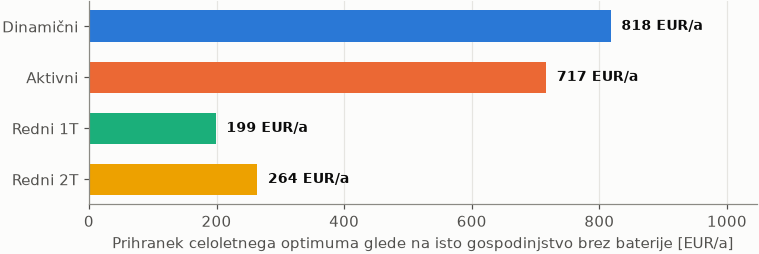

In [9]:
### What one point of gap is worth: the achievable saving on each list
fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.36))

vals = [achievable[t] for t in TARIFFS_READY]
ypos = np.arange(len(TARIFFS_READY))[::-1]

ax.barh(ypos, vals, height=0.62, color=[TARIFF_COLOR[t] for t in TARIFFS_READY])
for y, v in zip(ypos, vals):
    ax.annotate(f"{v:,.0f} EUR/a", xy=(v, y), xytext=(7, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9, fontweight="semibold")

ax.set_yticks(ypos, TARIFFS_READY)
ax.set_xlim(0, max(vals) * 1.28)
finish(ax, title="Imenovalec vseh spodnjih odstotkov",
       xlabel="Prihranek celoletnega optimuma glede na isto gospodinjstvo brez baterije [EUR/a]")
ax.grid(axis="y", visible=False)
pf.show(fig, "achievable_saving")

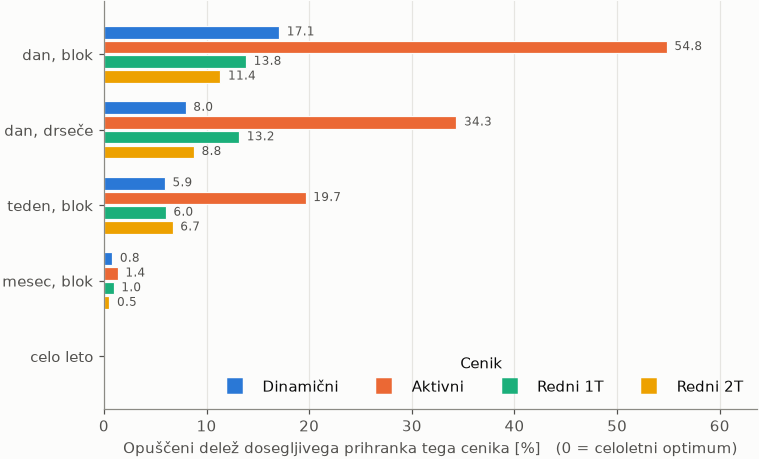

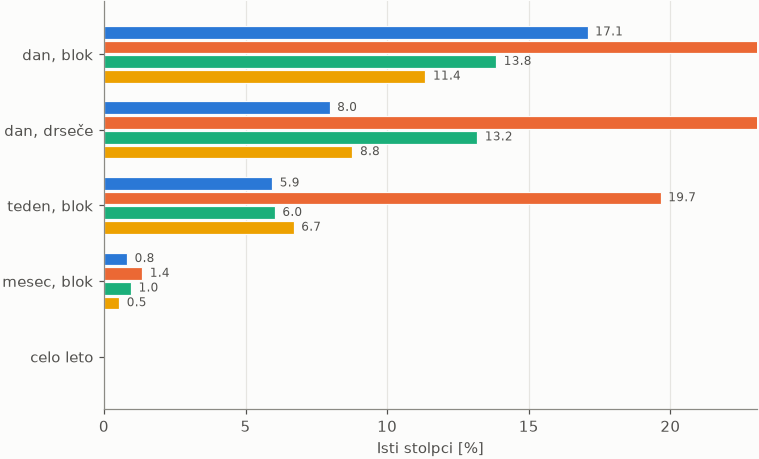

In [10]:
### What a shorter planning horizon costs, in % of the achievable saving
n_t = len(TARIFFS_READY)
group_h = 0.78
bar_h = group_h / n_t
base = np.arange(len(STRAT_ORDER))[::-1]


def gap_of(tariff, strat):
    return float(summary.loc[(tariff, strat), "Gap_pct"])


def draw_groups(ax, xmax):
    """One group of bars per strategy, one bar per price list, first list on top."""
    for i, tariff in enumerate(TARIFFS_READY):
        ypos = base + group_h / 2 - bar_h * (i + 0.5)
        gaps = [gap_of(tariff, s) for s in STRAT_ORDER]
        bars = ax.barh(ypos, gaps, height=bar_h * 0.86,   # surface gap between adjacent bars
                       color=[strat_color(tariff, s) for s in STRAT_ORDER],
                       edgecolor=SURFACE, linewidth=0.8)
        for patch, s in zip(bars, STRAT_ORDER):
            hatch = MODE_HATCH[hc.STRATEGIES[s][2]]
            if hatch:                   # carry, so the SOC mode is never colour-only
                patch.set_hatch(hatch)
                patch.set_edgecolor(pf.mix(TARIFF_COLOR[tariff], "#0b0b0b", 0.3))
        for y, v in zip(ypos, gaps):
            # Label only bars that round to something and fit on this axis.
            if v > 0.05 and v < xmax * 0.97:
                ax.annotate(fmt_pct(v), xy=(v, y), xytext=(5, 0), textcoords="offset points",
                            va="center", color=INK_2, fontsize=8)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--")
    ax.set_xlim(0, xmax)
    ax.set_ylim(-0.7, len(STRAT_ORDER) - 0.3)
    ax.set_yticks(base, [LABEL[s] for s in STRAT_ORDER])
    ax.grid(axis="y", visible=False)


# One list usually dwarfs the rest, so the full scale is one figure and the
# others get a zoom in a SECOND figure rather than a panel beside it: half of
# \textwidth is \columnwidth, and neither of these reads at that width.
widest = max(TARIFFS_READY, key=lambda t: max(gap_of(t, s) for s in STRAT_ORDER))
rest = [t for t in TARIFFS_READY if t != widest]
zoom_max = max((gap_of(t, s) for t in rest for s in STRAT_ORDER), default=0.0) * 1.35

fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
draw_groups(ax, max(float(summary["Gap_pct"].max()) * 1.16, 1.0))
finish(ax, title="Koliko stane krajši horizont načrtovanja, po cenikih",
       xlabel="Opuščeni delež dosegljivega prihranka tega cenika [%]   (0 = celoletni optimum)")
leg = tariff_legend(ax, where="lower right", title="Cenik")
if soc_mode_legend(ax, kind="patch", where="center right", title="Način SOC"):
    ax.add_artist(leg)
pf.show(fig, "horizon_gap_by_tariff")

if rest and zoom_max > 0:
    fig, ax_zoom = plt.subplots(figsize=pf.figsize(ratio=0.62))
    draw_groups(ax_zoom, max(zoom_max, 0.5))
    finish(ax_zoom,
           title=f"Povečava na {', '.join(rest)} ({widest} sega čez desni rob)",
           xlabel="Isti stolpci [%]")
    pf.show(fig, "horizon_gap_by_tariff_zoom")

findfont: Failed to find font weight semibold, now using 700.


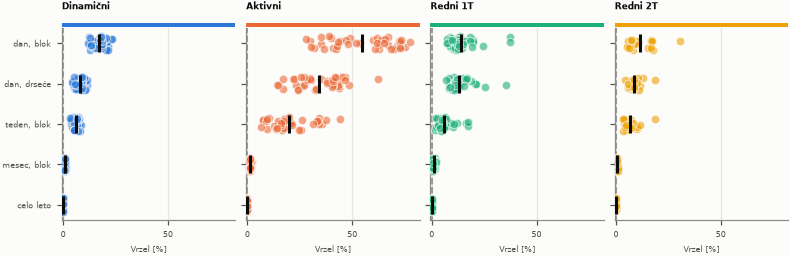

In [11]:
### Spread across households: one dot per household-unit, one panel per price list
# pf.panel_grid scales the panel text to the FINAL panel width, which is what
# keeps a row of four panels legible once it is squeezed to \textwidth.
fig, axes = pf.panel_grid(len(TARIFFS_READY), ncols=len(TARIFFS_READY),
                          panel=(4.0, 5.2), sharex=True, sharey=True)
rng = np.random.default_rng(0)
xmax = float(df_scored["Gap_pct"].max())

for ax, tariff in zip(axes, TARIFFS_READY):
    sub = df_scored[df_scored["Tariff"] == tariff]
    for i, strat in enumerate(STRAT_ORDER):
        y = len(STRAT_ORDER) - 1 - i
        vals = sub.loc[sub["Strategy"] == strat, "Gap_pct"]
        soc_mode = hc.STRATEGIES[strat][2]
        ax.scatter(vals, y + rng.uniform(-0.17, 0.17, len(vals)), s=30,
                   marker=MODE_MARKER[soc_mode], color=strat_color(tariff, strat),
                   alpha=0.6, lw=0.7, edgecolor=SURFACE, zorder=3)
        ax.scatter([vals.mean()], [y], s=140, marker="|", color=INK, lw=2.0, zorder=4)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--")
    panel_title(ax, tariff)
    ax.set_xlabel("Vrzel [%]")
    ax.grid(axis="y", visible=False)

axes[0].set_yticks(np.arange(len(STRAT_ORDER))[::-1], [LABEL[s] for s in STRAT_ORDER])
axes[0].set_xlim(-0.6, xmax * 1.06)

# One figure-level header and one shared key, measured in inches, in place of
# suptitle + legend + tight_layout.
pf.chart_frame(fig, "Vsako gospodinjstvo, vsaka strategija, vsak cenik",
               # chart_frame draws fig.legend, which reads each handle's own
               # label -- there is no labels= to pass alongside.
               handles=[plt.Line2D([], [], marker=MODE_MARKER[m], ls="", ms=8,
                                   color=MUTED, label=MODE_LABEL[m])
                        for m in SOC_MODES] if len(SOC_MODES) > 1 else None,
               ncol=2)
pf.show(fig, "gap_spread_households", layout="frame")

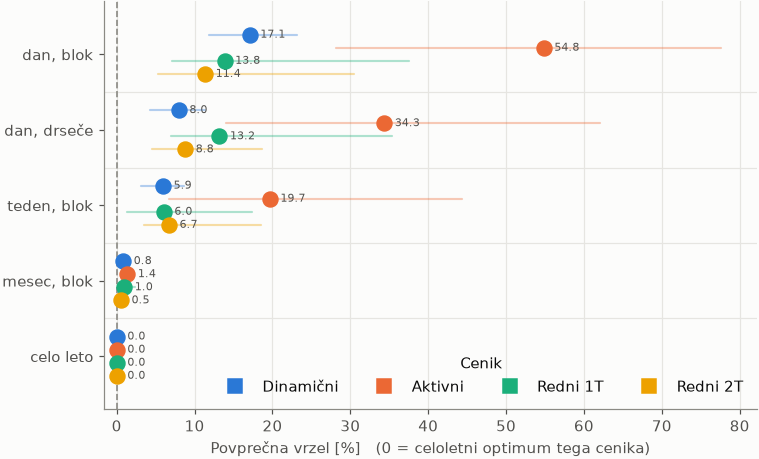

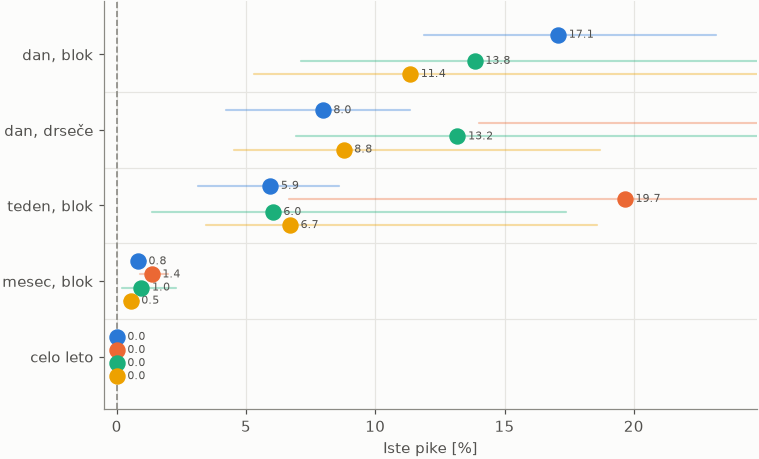

In [12]:
### Vsi ceniki na eni osi: povprečje po strategijah, ena pika na cenik
# The same averages on one shared axis, one dot per (cenik, strategija), so the
# ranking between lists reads directly. The thin bar behind each dot is
# best..worst household on that list.
row_off = np.linspace(0.26, -0.26, len(TARIFFS_READY))   # one lane per list inside a strategy band
base = np.arange(len(STRAT_ORDER))[::-1]


def draw_means(ax, xmax, labels=True):
    for i, tariff in enumerate(TARIFFS_READY):
        ypos = base + row_off[i]
        for y, strat in zip(ypos, STRAT_ORDER):
            row = summary.loc[(tariff, strat)]
            mean, lo, hi = (float(row["Gap_pct"]), float(row["Best_Gap_pct"]),
                            float(row["Worst_Gap_pct"]))
            ax.plot([lo, hi], [y, y], color=TARIFF_COLOR[tariff], lw=1.4, alpha=0.35,
                    solid_capstyle="round", zorder=2)
            ax.scatter([mean], [y], s=95, marker=MODE_MARKER[hc.STRATEGIES[strat][2]],
                       color=strat_color(tariff, strat), edgecolor=TARIFF_COLOR[tariff],
                       lw=1.0, zorder=4)
            # Direct value labels, so no dot is read by colour alone.
            if labels and mean < xmax * 0.93:
                ax.annotate(fmt_pct(mean), xy=(mean, y), xytext=(7, 0),
                            textcoords="offset points", va="center",
                            color=INK_2, fontsize=7.5)
    for y in base[:-1] - 0.5:           # one separator between strategy bands
        ax.axhline(y, color=pf.GRID, lw=0.8, zorder=1)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--", zorder=1)
    ax.set_xlim(-xmax * 0.02, xmax)
    ax.set_ylim(-0.7, len(STRAT_ORDER) - 0.3)
    ax.set_yticks(base, [LABEL[s] for s in STRAT_ORDER])
    ax.grid(axis="y", visible=False)


# Same full-scale / zoom split as the bar chart, and for the same reason it is
# two figures rather than two panels. The zoom is scaled on the averages, so the
# wider lists' spread bars run off its right edge.
widest = max(TARIFFS_READY,
             key=lambda t: max(float(summary.loc[(t, s), "Gap_pct"]) for s in STRAT_ORDER))
rest = [t for t in TARIFFS_READY if t != widest]
zoom_max = max((float(summary.loc[(t, s), "Gap_pct"]) for t in rest for s in STRAT_ORDER),
               default=0.0) * 1.45

fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
draw_means(ax, max(float(summary["Worst_Gap_pct"].max()) * 1.06, 1.0))
finish(ax, title="Povprečje vseh cenikov na eni osi",
       xlabel="Povprečna vrzel [%]   (0 = celoletni optimum tega cenika)")
leg = tariff_legend(ax, where="lower right", title="Cenik")
if soc_mode_legend(ax, kind="marker", where="center right", title="Način SOC"):
    ax.add_artist(leg)
pf.show(fig, "gap_means_all_tariffs")

if rest and zoom_max > 0:
    fig, ax_zoom = plt.subplots(figsize=pf.figsize(ratio=0.62))
    draw_means(ax_zoom, max(zoom_max, 0.5))
    finish(ax_zoom,
           title=f"Povečava na {', '.join(rest)} "
                 f"({widest} in daljši razponi segajo čez desni rob)",
           xlabel="Iste pike [%]")
    pf.show(fig, "gap_means_all_tariffs_zoom")

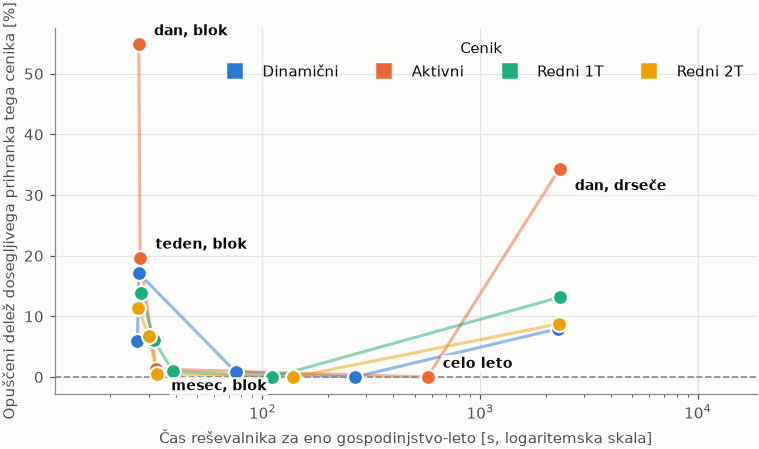

In [13]:
### What the extra compute buys, on each price list
fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.58))

for tariff in TARIFFS_READY:
    xs = np.array([summary.loc[(tariff, s), "Runtime_s"] for s in STRAT_ORDER], dtype=float)
    ys = np.array([summary.loc[(tariff, s), "Gap_pct"] for s in STRAT_ORDER], dtype=float)
    order = np.argsort(xs)
    # One list's trade-off curve, cheapest solve to most expensive.
    ax.plot(xs[order], ys[order], lw=2.0, color=TARIFF_COLOR[tariff], alpha=0.5, zorder=2)
    for strat, xi, yi in zip(STRAT_ORDER, xs, ys):
        ax.scatter([xi], [yi], s=95, marker=MODE_MARKER[hc.STRATEGIES[strat][2]],
                   color=strat_color(tariff, strat), zorder=3, lw=1.4, edgecolor=SURFACE)

# Label the strategies once, on the most spread-out list. Offsets alternate so
# the labels survive where three strategies collapse onto one corner.
anchor = max(TARIFFS_READY, key=lambda t: summary.loc[t, "Gap_pct"].max())
for k, strat in enumerate(STRAT_ORDER):
    ax.annotate(LABEL[strat],
                xy=(summary.loc[(anchor, strat), "Runtime_s"],
                    summary.loc[(anchor, strat), "Gap_pct"]),
                xytext=(10, 6 if k % 2 == 0 else -14), textcoords="offset points",
                color=INK, fontsize=9, fontweight="semibold", zorder=6,
                bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.85))

ax.set_xscale("log")
ax.set_xlim(float(summary["Runtime_s"].min()) / 2.4, float(summary["Runtime_s"].max()) * 8.0)
ax.axhline(0, color=MUTED, lw=1.1, ls="--")
finish(ax, title="Porabljen računski čas proti prihranjenemu denarju",
       xlabel="Čas reševalnika za eno gospodinjstvo-leto [s, logaritemska skala]",
       ylabel="Opuščeni delež dosegljivega prihranka tega cenika [%]")
leg = tariff_legend(ax, where="upper right", title="Cenik")
if soc_mode_legend(ax, kind="marker", where="center right", title="Način SOC"):
    ax.add_artist(leg)
pf.show(fig, "runtime_vs_gap")

findfont: Failed to find font weight semibold, now using 700.


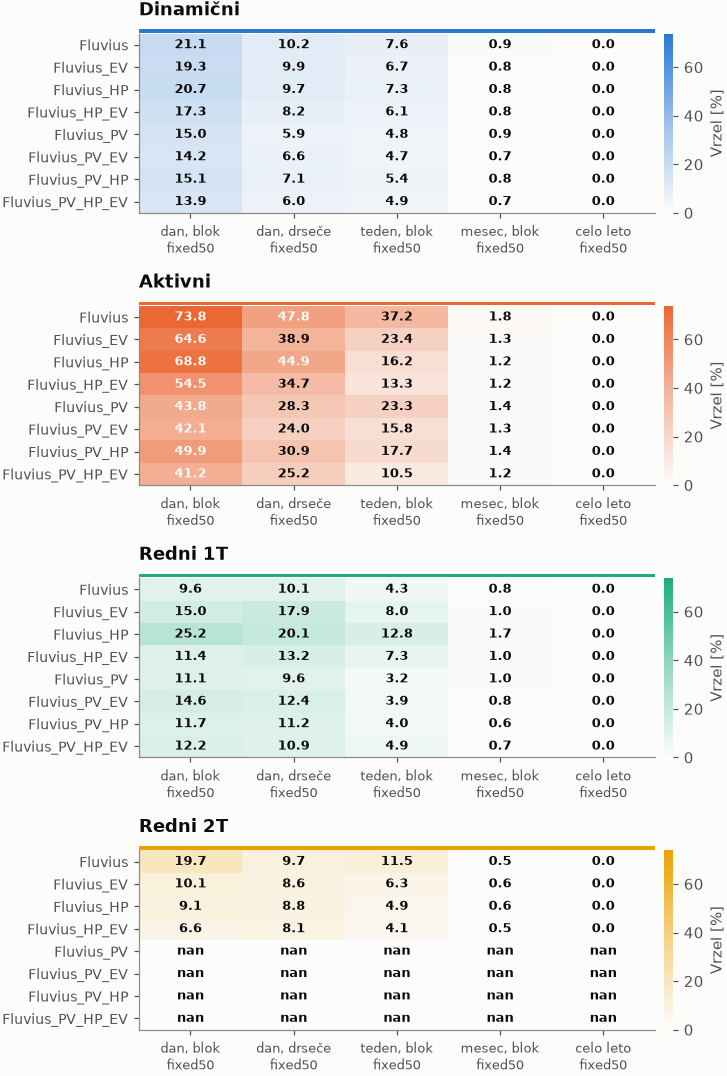

In [14]:
### Does the household type change the answer? One panel per price list, one hue per panel
plot_cols = [s for s in STRAT_ORDER if s != "full_period_carry"]
vmax = float(np.nanmax(by_group[[(t, s) for t in TARIFFS_READY for s in plot_cols]].to_numpy()))

# Stacked rather than side by side: the panels share the strategy axis, and one
# heatmap per row is still readable at \textwidth.
fig, axes = plt.subplots(len(TARIFFS_READY), 1, squeeze=False,
                         figsize=pf.figsize(ratio=0.36 * len(TARIFFS_READY)))

for ax, tariff in zip(axes[:, 0], TARIFFS_READY):
    values = by_group[[(tariff, s) for s in plot_cols]].to_numpy()
    im = ax.imshow(values, cmap=TARIFF_RAMP[tariff], aspect="auto", vmin=0, vmax=vmax)

    ax.set_xticks(range(len(plot_cols)),
                  [f"{LABEL[s]}\n{hc.STRATEGIES[s][2]}" for s in plot_cols], fontsize=8.5)
    ax.set_yticks(range(by_group.shape[0]), by_group.index, fontsize=9)
    ax.grid(visible=False)
    for r in range(values.shape[0]):
        for c in range(values.shape[1]):
            v = values[r, c]
            ax.annotate(fmt_pct(v), xy=(c, r), ha="center", va="center", fontsize=8.5,
                        color=SURFACE if v > 0.55 * vmax else INK, fontweight="semibold")
    panel_title(ax, tariff)
    cbar = fig.colorbar(im, ax=ax, pad=0.015)
    cbar.set_label("Vrzel [%]", color=INK_2)
    cbar.outline.set_visible(False)

pf.chart_frame(fig, f"Vrzel po tipu gospodinjstva in ceniku, enaka skala 0-{vmax:.0f} % "
                    "na vseh grafih")
pf.show(fig, "gap_by_group_and_tariff", layout="frame")

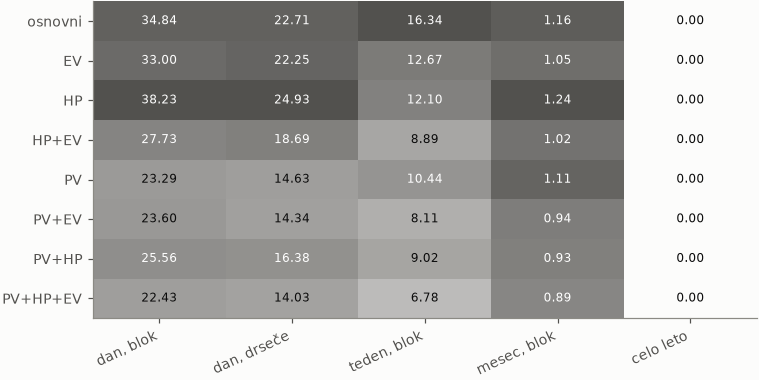

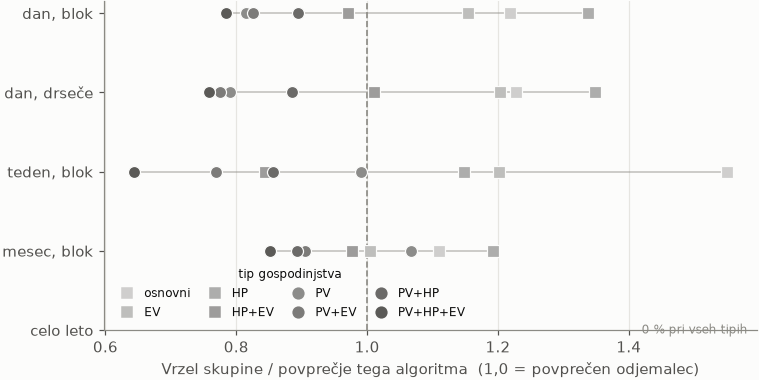

8 tipov gospodinjstev x 5 algoritmov, ceniki Dinamični, Aktivni, Redni 1T (skupine s PV in brez njega so na njih enako zastopane)

algoritem             najtežji tip   vrzel      najlažji tip   vrzel   razpon  PV / brez PV
dan, blok                       HP  38.23%          PV+HP+EV  22.43%   15.81         0.71x
dan, drseče                     HP  24.93%          PV+HP+EV  14.03%   10.90         0.67x
teden, blok                osnovni  16.34%          PV+HP+EV   6.78%    9.57         0.69x
mesec, blok                     HP   1.24%          PV+HP+EV   0.89%    0.36         0.87x
celo leto                       --   0.00%                --   0.00%    0.00            --

Spearman med algoritmi po uvrstitvi skupin: povprečno 0.82 (min 0.74) -- isti tipi so težki za vse algoritme
Najtežji tip po algoritmih: dan, blok -> HP, dan, drseče -> HP, teden, blok -> osnovni, mesec, blok -> HP
Združeno po evrih (pooled) je najtežji tip drugje: dan, blok -> osnovni (namesto HP), dan, drseče -> osnov

Strategy,"dan, blok","dan, drseče","teden, blok","mesec, blok",celo leto
Dataset,,,,,
Fluvius,34.84,22.71,16.34,1.16,0.0
Fluvius_EV,33.00,22.25,12.67,1.05,-0.0
Fluvius_HP,38.23,24.93,12.10,1.24,-0.0
Fluvius_HP_EV,27.73,18.69,8.89,1.02,0.0
Fluvius_PV,23.29,14.63,10.44,1.11,-0.0
Fluvius_PV_EV,23.60,14.34,8.11,0.94,-0.0
Fluvius_PV_HP,25.56,16.38,9.02,0.93,-0.0
Fluvius_PV_HP_EV,22.43,14.03,6.78,0.89,-0.0


In [15]:
### Kaj tip odjemalca naredi kakovosti MILP, po algoritmih
# The list is averaged out so the consumer is the only thing varying, over the
# lists every group may sign. Redni 2T is scoped to the no-PV groups, so leaving
# it in would read a contract difference as a household difference.
UNIVERSAL = [t for t in TARIFFS_READY
             if all(hc.tariff_allowed(t, g) for g in hc.DATASET_GROUPS)]
df_g = df_scored[df_scored["Tariff"].isin(UNIVERSAL)]
GROUPS = [g for g in hc.DATASET_GROUPS if g in set(df_g["Dataset"])]

gap_group = (df_g.pivot_table(index="Dataset", columns="Strategy", values="Gap_pct",
                              aggfunc="mean")
             .reindex(index=GROUPS, columns=STRAT_ORDER))
# Pooled per (group, strategy): summed gap over summed achievable.
gap_group_pooled = (
    df_g.groupby(["Dataset", "Strategy"])[["Gap_to_Optimum_EUR", "Achievable_EUR"]]
    .apply(hc._pooled_gap_pct).unstack("Strategy")
    .reindex(index=GROUPS, columns=STRAT_ORDER)
)
gap_eur_group = (df_g.pivot_table(index="Dataset", columns="Strategy",
                                  values="Gap_to_Optimum_EUR", aggfunc="mean")
                 .reindex(index=GROUPS, columns=STRAT_ORDER))

# Every algorithm is scored against its own column mean: the question is which
# consumer type an algorithm handles badly.
col_mean = gap_group.mean(axis=0)
rel = gap_group.div(col_mean.where(col_mean > 1e-9))     # 1.0 = that algorithm's average consumer
pv_mask = np.array([hc.has_pv(g) for g in GROUPS])


def short_group(g):
    """Fluvius_PV_HP_EV -> PV+HP+EV, and the bare group -> 'osnovni'."""
    return "osnovni" if g == "Fluvius" else g.replace("Fluvius_", "").replace("_", "+")

# --- the numbers themselves, colour-normalised per algorithm -----------------
# Each column is scaled to its own maximum; the printed number carries the
# magnitude. A neutral ramp: these rows pool the price lists, so neither list
# hue may claim them.
fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.52))
norm = gap_group.div(gap_group.max(axis=0).where(lambda s: s > 1e-9)).fillna(0.0)
ax.imshow(norm.to_numpy(), cmap=pf.ramp(INK_2, "spread"), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(STRAT_ORDER)), [LABEL[s] for s in STRAT_ORDER],
              rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(len(GROUPS)), [short_group(g) for g in GROUPS], fontsize=9)
ax.grid(False)
for r in range(len(GROUPS)):
    for c in range(len(STRAT_ORDER)):
        v = gap_group.iat[r, c]
        ax.text(c, r, fmt_pct(v, 2), ha="center", va="center", fontsize=8,
                color="#ffffff" if norm.iat[r, c] > 0.62 else INK)
finish(ax, title="Povprečna vrzel [%] po skupinah; senčenje je normirano po stolpcu, "
                 "temno = najtežji odjemalec za ta algoritem")
pf.show(fig, "gap_by_consumer_type")

# --- the same rows as a ratio, so the algorithms share one axis --------------
fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.52))
GROUP_SHADE = [pf.mix(INK_2, "#ffffff", t) for t in np.linspace(0.72, 0.05, len(GROUPS))]
base = np.arange(len(STRAT_ORDER))[::-1]
flat_rows = []
for j, strat in enumerate(STRAT_ORDER):
    y = base[j]
    vals = rel[strat].to_numpy()
    if not np.isfinite(vals).any():
        # The whole-year solve is 0 % on every type by construction, so there is
        # no ratio to draw.
        flat_rows.append(y)
        continue
    ax.plot([np.nanmin(vals), np.nanmax(vals)], [y, y], color=MUTED, lw=1.2,
            alpha=0.45, zorder=2)
    for i, g in enumerate(GROUPS):
        ax.scatter([vals[i]], [y], s=62, marker="o" if pv_mask[i] else "s",
                   color=GROUP_SHADE[i], edgecolor=SURFACE, lw=0.8, zorder=3)
ax.axvline(1.0, color=MUTED, lw=1.1, ls="--")
for y in flat_rows:
    ax.annotate("0 % pri vseh tipih", xy=(1.0, y), xycoords=("axes fraction", "data"),
                xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                fontsize=8, color=MUTED)
ax.set_yticks(base, [LABEL[s] for s in STRAT_ORDER])
finish(ax, title="Tip odjemalca proti kakovosti MILP: krog = s PV, kvadrat = brez PV",
       xlabel="Vrzel skupine / povprečje tega algoritma  (1,0 = povprečen odjemalec)")
ax.grid(axis="y", visible=False)
pf.key_legend(ax, [plt.Line2D([], [], marker="o" if pv_mask[i] else "s", ls="", ms=7,
                              color=GROUP_SHADE[i]) for i in range(len(GROUPS))],
              where="lower left", ncol=4,
              labels=[short_group(g) for g in GROUPS], fontsize=8,
              title="tip gospodinjstva", title_fontsize=8, columnspacing=1.0,
              handletextpad=0.4)
pf.show(fig, "gap_by_consumer_type_ratio")

# --- read-out -------------------------------------------------------------
lines = [
    f"{len(GROUPS)} tipov gospodinjstev x {len(STRAT_ORDER)} algoritmov, "
    f"ceniki {', '.join(UNIVERSAL)} (skupine s PV in brez njega so na njih enako zastopane)",
    "",
    f"{'algoritem':16s}{'najtežji tip':>18s}{'vrzel':>8s}{'najlažji tip':>18s}{'vrzel':>8s}"
    f"{'razpon':>9s}{'PV / brez PV':>14s}",
]
for strat in STRAT_ORDER:
    col = gap_group[strat].dropna()
    if col.empty or col.max() <= 1e-9:
        lines.append(f"{LABEL[strat]:16s}{'--':>18s}{0.0:7.2f}%{'--':>18s}{0.0:7.2f}%"
                     f"{0.0:8.2f}{'--':>14s}")
        continue
    hi, lo = col.idxmax(), col.idxmin()
    pv_mean = float(gap_group.loc[pv_mask, strat].mean())
    no_pv_mean = float(gap_group.loc[~pv_mask, strat].mean())
    ratio = pv_mean / no_pv_mean if no_pv_mean > 1e-9 else float("nan")
    lines.append(
        f"{LABEL[strat]:16s}{short_group(hi):>18s}{col[hi]:7.2f}%"
        f"{short_group(lo):>18s}{col[lo]:7.2f}%"
        f"{col.max() - col.min():8.2f}{ratio:13.2f}x"
    )

# Is "hard household" a property of the household? A high rank correlation
# across algorithms means the consumer type is a fixed handicap.
ranks = gap_group[[s for s in STRAT_ORDER if gap_group[s].max() > 1e-9]].rank(axis=0)
corr = ranks.corr(method="spearman")
off = corr.to_numpy()[np.triu_indices(len(corr), k=1)] if len(corr) > 1 else np.array([])
worst_each = {s: gap_group[s].idxmax() for s in ranks.columns}
lines += [
    "",
    f"Spearman med algoritmi po uvrstitvi skupin: povprečno {np.nanmean(off):.2f} "
    f"(min {np.nanmin(off):.2f}) -- "
    + ("isti tipi so težki za vse algoritme" if np.nanmean(off) > 0.6
       else "vsak algoritem se lomi na svojem tipu odjemalca"),
    f"Najtežji tip po algoritmih: "
    + ", ".join(f"{LABEL[s]} -> {short_group(g)}" for s, g in worst_each.items()),
]
# Where the mean of percentages and the pooled gap disagree about which type is
# hardest, the disagreement is printed rather than averaged away.
disagree = [(s_, worst_each[s_], gap_group_pooled[s_].idxmax()) for s_ in ranks.columns
            if gap_group_pooled[s_].notna().any()
            and gap_group_pooled[s_].idxmax() != worst_each[s_]]
lines += [
    ("Združeno po evrih (pooled) je najtežji tip drugje: "
     + ", ".join(f"{LABEL[s_]} -> {short_group(p_)} (namesto {short_group(m_)})"
                 for s_, m_, p_ in disagree))
    if disagree else
    "Združeno po evrih (pooled) je najtežji tip povsod isti kot po povprečju odstotkov",
    "",
    "V evrih (povprečna zamujena letna korist na gospodinjstvo tega tipa):",
    f"{'algoritem':16s}" + "".join(f"{short_group(g):>16s}" for g in GROUPS[:4]),
]
for strat in STRAT_ORDER:
    lines.append(f"{LABEL[strat]:16s}"
                 + "".join(f"{gap_eur_group.loc[g, strat]:15.2f}" for g in GROUPS[:4]))
lines.append(f"{'algoritem':16s}" + "".join(f"{short_group(g):>16s}" for g in GROUPS[4:]))
for strat in STRAT_ORDER:
    lines.append(f"{LABEL[strat]:16s}"
                 + "".join(f"{gap_eur_group.loc[g, strat]:15.2f}" for g in GROUPS[4:]))

print("\n".join(lines))

gap_group.rename(columns=LABEL).round(2)

## 5. Read-out

In [16]:
lines = [
    f"{len(balanced)} household-units "
    f"({hc.HOUSEHOLDS_PER_GROUP} x {len(hc.DATASET_GROUPS)} Fluvius groups), "
    f"{hc.BATTERY_CAPACITY_KWH:.0f} kWh battery, full year, "
    f"{len(TARIFFS_READY)} price lists",
]

for tariff in TARIFFS_READY:
    tab = summary.loc[tariff]
    spec = hc.TARIFFS[tariff]
    fixed = [s for s in STRAT_ORDER if hc.STRATEGIES[s][2] == "fixed50"]
    non_optimal = [s for s in STRAT_ORDER if tab.loc[s, "Gap_pct"] > 1e-9]
    best = tab.loc[non_optimal, "Gap_pct"].idxmin() if non_optimal else STRAT_ORDER[0]
    grid_share = 100.0 * tab.loc[hc.REFERENCE_STRATEGY, "Grid_Charged_kWh"] / max(
        tab.loc[hc.REFERENCE_STRATEGY, "Charged_kWh"], 1e-9)

    lines += [
        "",
        "=" * 78,
        f"{tariff}  ({spec['paket_id']}, {spec['structure']}, "
        f"{'exports credited' if spec['buyback'] else 'no buyback'})",
        f"achievable saving {achievable[tariff]:.2f} EUR/a, so 1 pt of gap = "
        f"{achievable[tariff] / 100:.2f} EUR/a; the whole-year solve charges "
        f"{grid_share:.0f} % of its throughput off the grid",
        "",
        f"{'strategy':16s}{'SOC mode':10s}{'gap %':>8s}{'worst':>8s}{'gap EUR/a':>11s}"
        f"{'solves':>9s}{'time':>9s}",
    ]
    for strat in STRAT_ORDER:
        r = tab.loc[strat]
        lines.append(
            f"{LABEL[strat]:16s}{r['SOC_Mode']:10s}{r['Gap_pct']:7.2f}%{r['Worst_Gap_pct']:7.2f}%"
            f"{r['Gap_EUR']:11.2f}{r['Solves']:9,.0f}{r['Runtime_s']:8.0f}s"
        )

    pairs = [(a, f"{a}_carry") for a in fixed if f"{a}_carry" in tab.index]
    if pairs:
        lines += ["", "  Same horizon and execution, the two SOC modes side by side:"]
        for a, b in pairs:
            delta = tab.loc[b, "Gap_pct"] - tab.loc[a, "Gap_pct"]
            verdict = ("identical" if abs(delta) <= 0.005
                       else "carry is worse" if delta > 0 else "carry is better")
            lines.append(f"     {LABEL[a]:16s} {tab.loc[a, 'Gap_pct']:6.2f}% -> "
                         f"{tab.loc[b, 'Gap_pct']:6.2f}%  ({delta:+.2f} pts, {verdict})")

    steps = [("day_block", "week_block"), ("week_block", "month_block"),
             ("month_block", "full_period"),
             ("day_block_carry", "week_block_carry"),
             ("week_block_carry", "month_block_carry")]
    lines += ["", "  Longer horizon, same execution and SOC mode:"]
    for a, b in steps:
        if a in tab.index and b in tab.index:
            lines.append(f"     {LABEL[a]:16s} -> {LABEL[b]:16s} "
                         f"{tab.loc[a, 'Gap_pct'] - tab.loc[b, 'Gap_pct']:+6.2f} pts "
                         f"({hc.STRATEGIES[a][2]})")

    lines += ["", "  Re-planning every interval instead of committing to the block:"]
    for a, b in (("day_block", "day_receding"), ("day_block_carry", "day_receding_carry")):
        if a in tab.index and b in tab.index:
            lines.append(f"     {LABEL[a]:16s} {hc.STRATEGIES[a][2]:8s} "
                         f"{tab.loc[a, 'Gap_pct']:6.2f}% -> {tab.loc[b, 'Gap_pct']:6.2f}%  "
                         f"({tab.loc[b, 'Solves'] / tab.loc[a, 'Solves']:.0f}x the solves, "
                         f"{tab.loc[b, 'Runtime_s'] / max(tab.loc[a, 'Runtime_s'], 1e-9):.0f}x "
                         f"the time)")

    lines += ["", f"  Best non-clairvoyant strategy: {LABEL[best]} ({hc.STRATEGIES[best][2]}), "
                  f"{tab.loc[best, 'Gap_pct']:.2f} % short of the optimum "
                  f"({tab.loc[best, 'Gap_EUR']:.2f} EUR/a)"]

    spread = by_group[tariff].max(axis=0) - by_group[tariff].min(axis=0)
    lines += ["", "  Spread of the mean gap across the 8 household types [pts]:"]
    for strat in STRAT_ORDER:
        if strat in spread.index and spread[strat] > 1e-9:
            lines.append(f"     {LABEL[strat]:16s} {hc.STRATEGIES[strat][2]:8s} "
                         f"{spread[strat]:5.2f}")

lines += ["", "=" * 78, "Across the price lists", ""]
lines.append(f"{'price list':12s}{'structure':21s}{'achievable':>12s}"
             + "".join(f"{LABEL[s]:>16s}" for s in STRAT_ORDER))
for tariff in TARIFFS_READY:
    lines.append(
        f"{tariff:12s}{hc.TARIFFS[tariff]['structure']:21s}"
        f"{achievable[tariff]:10.0f}  "
        + "".join(f"{summary.loc[(tariff, s), 'Gap_pct']:15.2f}%" for s in STRAT_ORDER)
    )

day = {t: summary.loc[(t, 'day_block'), "Gap_pct"] for t in TARIFFS_READY
       if (t, "day_block") in summary.index}
if len(day) > 1:
    hardest, easiest = max(day, key=day.get), min(day, key=day.get)
    lines += [
        "",
        f"A day-ahead block controller gives up {day[hardest]:.2f} % on {hardest} and "
        f"{day[easiest]:.2f} % on {easiest}",
        f"-- {day[hardest] / max(day[easiest], 1e-9):.0f}x more of the achievable saving, "
        f"and {summary.loc[(hardest, 'day_block'), 'Gap_EUR']:.2f} against "
        f"{summary.loc[(easiest, 'day_block'), 'Gap_EUR']:.2f} EUR/a in money.",
        "The horizon question is a question about the price signal, not about the solver.",
    ]

print("\n".join(lines))

40 household-units (5 x 8 Fluvius groups), 30 kWh battery, full year, 4 price lists

Dinamični  (GENI_SAMO_DINAMICNI, dynamic (SIPX), exports credited)
achievable saving 817.79 EUR/a, so 1 pt of gap = 8.18 EUR/a; the whole-year solve charges 89 % of its throughput off the grid

strategy        SOC mode     gap %   worst  gap EUR/a   solves     time
dan, blok       fixed50     17.07%  23.16%     137.19      366      27s
dan, drseče     fixed50      7.97%  11.33%      63.98   35,135    2287s
teden, blok     fixed50      5.94%   8.61%      47.58       53      27s
mesec, blok     fixed50      0.82%   1.15%       6.60       12      75s
celo leto       fixed50     -0.00%   0.00%       0.00        1     266s

  Longer horizon, same execution and SOC mode:
     dan, blok        -> teden, blok      +11.13 pts (fixed50)
     teden, blok      -> mesec, blok       +5.12 pts (fixed50)
     mesec, blok      -> celo leto         +0.82 pts (fixed50)

  Re-planning every interval instead of committing 

In [17]:
### The same table with the price list averaged out
# One row per strategy over every (household, price list) run in the balanced
# panel. The mean is over runs, not over the four lists: the panel is not
# balanced across lists, so averaging four list-means would overweight the 20
# units eligible for Redni 2T. The equal-weight-per-contract mean is printed
# beside it wherever the two disagree by more than 0.05 pts.
across = df_scored.groupby("Strategy").agg(
    Runs=("Gap_pct", "size"),
    SOC_Mode=("SOC_Mode", "first"),
    Gap_pct=("Gap_pct", "mean"),
    Worst_Gap_pct=("Gap_pct", "max"),
    Gap_EUR=("Gap_to_Optimum_EUR", "mean"),
    Solves=("N_Solves", "mean"),
    Runtime_s=("Runtime_s", "mean"),
).reindex(STRAT_ORDER)

# Pooled over every run on every list: summed gap over summed achievable.
across["Gap_pct_pooled"] = (
    df_scored.groupby("Strategy")[["Gap_to_Optimum_EUR", "Achievable_EUR"]]
    .apply(hc._pooled_gap_pct).reindex(STRAT_ORDER)
)
# Every contract weighted equally, whatever its sample size.
by_contract = summary["Gap_pct"].groupby("Strategy").mean().reindex(STRAT_ORDER)

# The worst single run, named with the contract it was on.
worst_where = (
    df_scored.loc[df_scored.groupby("Strategy")["Gap_pct"].idxmax().dropna()]
    .set_index("Strategy")[["Tariff", "Dataset", "Household"]]
)

lines = [
    f"Povprečje čez vse cenike -- {len(balanced)} gospodinjstev, "
    f"{len(TARIFFS_READY)} ceniki ({', '.join(TARIFFS_READY)}), "
    f"{hc.BATTERY_CAPACITY_KWH:.0f} kWh baterija, celo leto",
    f"{int(across['Runs'].max())} zagonov na strategijo; povprečje je čez zagone, "
    f"ne čez cenike (panel ni uravnotežen: "
    + ", ".join(f"{t} {int(summary.loc[(t, STRAT_ORDER[0]), 'Units'])}" for t in TARIFFS_READY)
    + " enot)",
    "",
    f"{'strategy':16s}{'SOC mode':10s}{'gap %':>8s}{'worst':>8s}{'gap EUR/a':>11s}"
    f"{'solves':>9s}{'time':>9s}",
]
for strat in STRAT_ORDER:
    r = across.loc[strat]
    lines.append(
        f"{LABEL[strat]:16s}{r['SOC_Mode']:10s}{r['Gap_pct']:7.2f}%{r['Worst_Gap_pct']:7.2f}%"
        f"{r['Gap_EUR']:11.2f}{r['Solves']:9,.0f}{r['Runtime_s']:8.0f}s"
    )

lines += ["", f"{'strategy':16s}{'pooled %':>10s}{'po ceniku %':>13s}{'najslabši zagon':>18s}"]
for strat in STRAT_ORDER:
    r, w = across.loc[strat], worst_where.loc[strat]
    alt = f"{by_contract[strat]:12.2f}%" if abs(by_contract[strat] - r["Gap_pct"]) > 0.05 else \
        f"{'=':>13s}"
    lines.append(f"{LABEL[strat]:16s}{r['Gap_pct_pooled']:9.2f}%{alt}"
                 f"   {w['Tariff']}, {w['Dataset']} #{int(w['Household'])}")

non_optimal = [s for s in STRAT_ORDER if across.loc[s, "Gap_pct"] > 1e-9]
if non_optimal:
    best = across.loc[non_optimal, "Gap_pct"].idxmin()
    lines += [
        "",
        f"Najboljša strategija brez jasnovidnosti, povprečno čez cenike: {LABEL[best]} "
        f"({across.loc[best, 'SOC_Mode']}), {across.loc[best, 'Gap_pct']:.2f} % "
        f"({across.loc[best, 'Gap_EUR']:.2f} EUR/a) do optimuma",
        f"Razpon istega povprečja po cenikih: "
        + ", ".join(f"{t} {summary.loc[(t, best), 'Gap_pct']:.2f} %" for t in TARIFFS_READY),
    ]

print("\n".join(lines))

across.rename(columns={
    "Runs": "Runs", "SOC_Mode": "SOC mode", "Gap_pct": "Vrzel [%]",
    "Gap_pct_pooled": "Gap pooled [%]", "Worst_Gap_pct": "Worst run [%]",
    "Gap_EUR": "Gap [EUR/a]", "Solves": "MILP solves", "Runtime_s": "Solver time [s]",
}).round(2)

Povprečje čez vse cenike -- 40 gospodinjstev, 4 ceniki (Dinamični, Aktivni, Redni 1T, Redni 2T), 30 kWh baterija, celo leto
140 zagonov na strategijo; povprečje je čez zagone, ne čez cenike (panel ni uravnotežen: Dinamični 40, Aktivni 40, Redni 1T 40, Redni 2T 20 enot)

strategy        SOC mode     gap %   worst  gap EUR/a   solves     time
dan, blok       fixed50     26.12%  77.54%     158.91      366      27s
dan, drseče     fixed50     17.11%  62.08%      96.04   35,135    2315s
teden, blok     fixed50      9.99%  44.36%      56.25       53      29s
mesec, blok     fixed50      0.97%   2.29%       5.29       12      47s
celo leto       fixed50     -0.00%   0.00%       0.00        1     291s

strategy          pooled %  po ceniku %   najslabši zagon
dan, blok           29.82%       24.28%   Aktivni, Fluvius #5
dan, drseče         18.02%       16.07%   Aktivni, Fluvius #5
teden, blok         10.56%        9.58%   Aktivni, Fluvius #5
mesec, blok          0.99%        0.92%   Redni 1T, 

,Runs,SOC mode,Vrzel [%],Worst run [%],Gap [EUR/a],MILP solves,Solver time [s],Gap pooled [%]
Strategy,,,,,,,,
day_block,140,fixed50,26.12,77.54,158.91,366.0,27.23,29.82
day_receding,140,fixed50,17.11,62.08,96.04,35135.0,2314.76,18.02
week_block,140,fixed50,9.99,44.36,56.25,53.0,28.81,10.56
month_block,140,fixed50,0.97,2.29,5.29,12.0,46.60,0.99
full_period,140,fixed50,-0.00,0.00,0.00,1.0,291.46,0.00


### Caveats

* **Every strategy still has perfect foresight inside its horizon**, so these gaps are a lower
  bound on what a short horizon costs in practice — loosest on Dinamični, whose price signal is
  the one nobody can forecast, and tightest on the Redni lists, where the supplier price is
  known a year ahead by contract.
* **A percentage on one list is not a percentage on another.** `Gap_pct` divides by that list's
  own achievable saving; `Achievable [EUR/a]` and `Gap [EUR/a]` settle comparisons across lists.
* **Watch the grid-charged share on the block lists.** `Aktivni` has a fixed 4-block spread
  known to the solver a year in advance, so a battery can arbitrage it every day regardless of
  PV. Where `Grid charged [%]` is high, the achievable saving is arbitrage, not stored
  production, and a day is nearly enough horizon to capture it.
* **`carry` is not automatically better.** Stored energy has no value in an objective that stops
  at the horizon end, so a block strategy under `carry` runs the battery flat at every boundary.
  A terminal value on stored energy, not a terminal constraint, is the fix.
* **`full_period_carry` is identical to `full_period` by construction** — one period, pinned at
  both ends — and is kept as a consistency check on the SOC bookkeeping.
* **The excess-power charge resets every month** (`hc.PEAK_RESET_MONTHS = 1`) on both sides, so
  a household pays the excess twelve times a year and a battery that shaves it earns twelve
  times. Rows tagged `Peak_Reset = "never"` are dropped by `hc.collect_results`.
* **The agreed power is per block and per month**, so the excess charge is measured against a
  contract that tracks the household. Rows tagged `Agreed_Power = "flat_peak_over_1.5"` are
  dropped for the same reason.
* **Choosing your own agreed power is what makes the excess charge payable.** A household that
  leaves its assigned figure alone is exempt; the one modelled here is not, and pays 1.05 x the
  block power rate on the exceedance.
* **Three of the four lists formally require PV** (`zahteva_pv=True`). They are applied to the
  no-PV groups here to measure the import side alone; `No_battery_comparison.ipynb` asks which
  list a no-PV household could actually sign.
* **`full_period` carries a 0.1 % MIP gap** (`hc.FULL_PERIOD_GAP_REL`), which is why a
  `full_period` gap prints as -0.00 % on some units.